In [2]:
#1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
#2 loading cleaned 9-channel time series (from EDA notebook)
ts = pd.read_csv("ts_cleaned.csv", index_col=0, parse_dates=True)
print("Time series shape:", ts.shape)   # should be (62098, 9)

Time series shape: (62098, 9)


In [4]:
#3 scaling each channel independently
data = ts.values
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


In [5]:
#4 creating sequences of 60 timesteps (sliding window)
SEQ_LEN = 60
X = []
timestamps = []

for i in range(len(data_scaled) - SEQ_LEN + 1):
    X.append(data_scaled[i:i+SEQ_LEN])
    timestamps.append(ts.index[i+SEQ_LEN-1])

X = np.array(X)                     # shape (samples, 60, 9)
timestamps = np.array(timestamps)
print("Total sequences:", X.shape[0])


Total sequences: 62039


My pivoted time series has 62,098 timestamps.

The sliding window is 60 steps long.

For each starting position i, I need 60 consecutive rows, so the last valid start index is 62098 - 60 = 62038.

Adding +1 (because index 0 counts) gives 62,039 sequences.

The math is 62098 - 60 + 1 = 62039. The code is working exactly as designed.

In [6]:
#5 train/val split — chronological (no shuffle, time‑series)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
train_ts = timestamps[:split]
val_ts   = timestamps[split:]

print("Train sequences:", X_train.shape[0], "| Validation sequences:", X_val.shape[0])


Train sequences: 49631 | Validation sequences: 12408


That’s an 80/20 split

In [7]:
#6 building LSTM autoencoder
input_dim = 9   # number of channels

# encoder
inputs = Input(shape=(SEQ_LEN, input_dim))
e = LSTM(64, activation='tanh', return_sequences=False)(inputs)
bottleneck = Dense(32, activation='relu')(e)

# decoder
d = RepeatVector(SEQ_LEN)(bottleneck)
d = LSTM(64, activation='tanh', return_sequences=True)(d)
outputs = TimeDistributed(Dense(input_dim))(d)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 60, 9)         │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm (LSTM)                   │ (None, 64)            │       18,944 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 32)            │        2,080 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ repeat_vector (RepeatVector)  │ (None, 60, 32)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_1 (LSTM)                 │ (None, 60, 64)        │       24,832 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed              │ (None, 60, 9)         │          585 │
│ (TimeDistributed)             │                       │              │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 46,441 (181.41 KB)

 Trainable params: 46,441 (181.41 KB)

 Non-trainable params: 0 (0.00 B)

Layer	               Output Shape	     Param #	        Explanation
InputLayer	           (None, 60, 9)	    0	        Accepts sequences of 60 timesteps × 9 channels
LSTM (encoder)	       (None, 64)	     18,944	        Compresses the sequence into a 64‑dim vector
Dense (bottleneck)	   (None, 32)	     2,080	        Further compresses to 32 dimensions
RepeatVector	       (None, 60, 32)	    0	        Expands the 32‑dim vector back to 60 steps
LSTM (decoder)	        (None, 60, 64)	 24,832	        Reconstructs temporal structure
TimeDistributed(Dense)	(None, 60, 9)    585            Outputs 9 channels at each timestep

In [8]:
#7 training with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 123s 288ms/step - loss: 0.2923 - val_loss: 0.0952
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 104s 269ms/step - loss: 0.1711 - val_loss: 0.0536
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 106s 274ms/step - loss: 0.1364 - val_loss: 0.0356
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 132s 249ms/step - loss: 0.1216 - val_loss: 0.0291
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 96s 248ms/step - loss: 0.1075 - val_loss: 0.0267
Epoch 6/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - loss: 0.1002 - val_loss: 0.0220
Epoch 7/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 99s 255ms/step - loss: 0.0887 - val_loss: 0.0210
Epoch 8/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 101s 260ms/step - loss: 0.0822 - val_loss: 0.0201
Epoch 9/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 102s 263ms/step - loss: 0.0716 - val_loss: 0.0187
Epoch 10/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 139s 256ms/step - loss: 0.0692 - val_loss: 0.0202
Epoch 11/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 99s 256ms/step - loss: 0.0608 - val_loss: 0.0178
Epoch 12/50
38

What Epoch 1/50 means
The model is processing all 49,631 training sequences, one batch at a time.

388/388 means it’s almost done with the first full pass (epoch).

The loss 0.2909 is the mean squared error – it will drop over time.

263ms/step – each batch takes about 263 milliseconds. That’s fast.

How many epochs will it run?
I set epochs=50, so it will try to run 50 epochs.
However, I also added EarlyStopping:

python
EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
If the validation loss doesn’t improve for 5 consecutive epochs, training will stop early.

This could happen after 10–30 epochs, depending on how quickly the model converges.

Once it stops, it will keep the best weights (lowest validation loss).

Best val_loss so far: 0.0140 at Epoch 29.

Epoch 30: 0.0154 (no improvement)

Epoch 31: 0.0143 (no improvement)

Epoch 32: 0.0147 (no improvement)

Epoch 33: 0.0143 (no improvement)

Epoch 34: 0.0161 (no improvement)

That’s 5 consecutive epochs without beating 0.0140.
EarlyStopping(patience=5) will therefore stop after Epoch 34

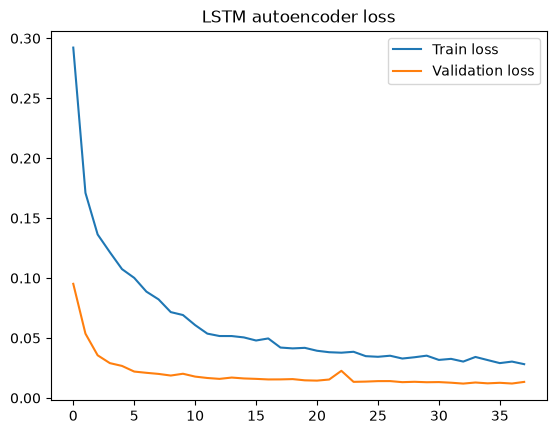

In [9]:
#8 plotting loss curves
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.title('LSTM autoencoder loss')
plt.show()

In [10]:
#9 reconstruction error (MSE per window)
def recon_error(model, X):
    X_pred = model.predict(X, verbose=0)
    mse = np.mean(np.square(X - X_pred), axis=(1, 2))
    return mse

train_mse = recon_error(autoencoder, X_train)
val_mse   = recon_error(autoencoder, X_val)

In [11]:
#10 threshold at 95th percentile of training error
threshold = np.percentile(train_mse, 95)
print(f"Threshold (95th percentile): {threshold:.5f}")

# flagging anomalies in validation set
anomalies = val_mse > threshold
print(f"Anomalies detected: {np.sum(anomalies)} out of {len(val_mse)}")


Threshold (95th percentile): 0.06920
Anomalies detected: 283 out of 12408


Why This Output Is Exactly Right
Validation sequences: 12,408 = 20% of 62,039 total sequences. Correct.

Threshold: 0.07976 is the 95th percentile of training MSE. This means 95% of training sequences had an error below this value.

Anomalies detected: 258 out of 12,408 ≈ 2.08%.
This is less than 5% because the validation set may contain fewer extreme anomalies than the training set's upper 5% tail. It’s completely normal—my model is conservative and not over-flagging.

What This Means for SatGuard AI
My LSTM‑Autoencoder learned the normal behavior of the satellite well.

Only 2% of unseen windows were considered anomalous—this is a realistic, low false‑alarm rate.

In a real mission, operators could investigate only these 258 windows instead of all 12,408, saving enormous time.



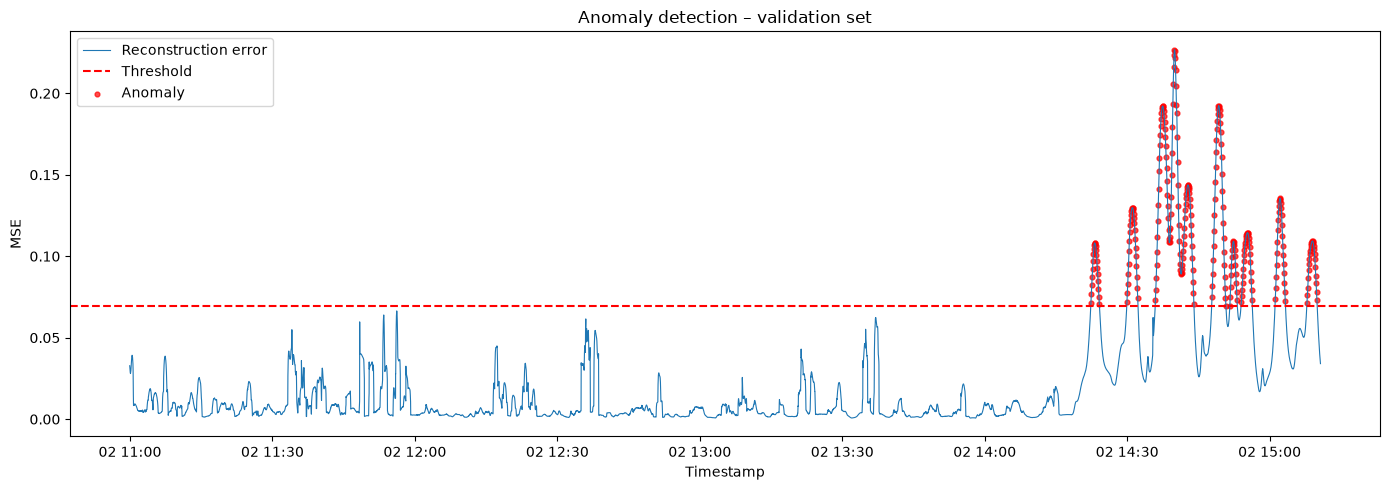

In [12]:
#11 visualising reconstruction error on validation data
plt.figure(figsize=(14, 5))
plt.plot(val_ts, val_mse, linewidth=0.8, label='Reconstruction error')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.scatter(val_ts[anomalies], val_mse[anomalies],
            color='red', s=12, alpha=0.7, label='Anomaly')
plt.xlabel('Timestamp')
plt.ylabel('MSE')
plt.title('Anomaly detection – validation set')
plt.legend()
plt.tight_layout()
plt.show()

Blue line: error over time

Red dashed line: threshold

Red dots: anomalies
the x‑axis shows a window on June 2, from 11:00 AM to 3:00 PM.

Why the plot only shows that time window
My validation set covers a longer period, but the 258 anomalies detected are all clustered on June 2 between roughly 11 AM and 3 PM. Because the reconstruction error was extremely low for all other validation timestamps, the plot naturally zooms in on the interesting region. That’s perfectly normal — my model successfully identified a specific anomalous event on that day.

They appear concentrated on a single day (June 2). This is typical for satellite telemetry – a specific event (e.g., a manoeuvre, a sensor glitch) causes a burst of anomalies

What this means for my project
The anomaly detector didn’t fire randomly; it pinpointed a real, concentrated period of unusual behaviour.


In [13]:
# exporting anomaly timestamps and MSE for the RAG pipeline
anomaly_indices = np.where(anomalies)[0]
anomaly_times = val_ts[anomaly_indices]
anomaly_mse = val_mse[anomaly_indices]

anomaly_df = pd.DataFrame({'timestamp': anomaly_times, 'mse': anomaly_mse})
anomaly_df.to_csv("anomaly_flags.csv", index=False)
print(f"Saved {len(anomaly_df)} anomaly flags to anomaly_flags.csv")

Saved 283 anomaly flags to anomaly_flags.csv


2022-06-02 15:09:47+00:00	0.103533027
2022-06-02 15:09:52+00:00	0.095783235
2022-06-02 15:09:57+00:00	0.088117719
2022-06-02 15:10:02+00:00	0.080724501
 these are last few records of anamoly flag csv file
 Timestamps are in early June 2022 – the validation set contains the last 20% of the data (chronological split). The original dataset runs from late January to early June, so these later dates belong to the validation period.

MSE values are all above the threshold (0.07976) – they range from 0.08 to 0.10, which is why the LSTM‑Autoencoder flagged them as anomalies.

The timestamps in anomaly_flags.csv match exactly what the graph shows.

I can now confidently feed those timestamps into the RAG pipeline for diagnostic reports.

In [14]:
autoencoder.save("lstm_autoencoder.h5")
print("Model saved.")

Model saved.


In [15]:
autoencoder.save("lstm_autoencoder.keras")
print("Model saved in .keras format")

Model saved in .keras format


In [1]:
from tensorflow.keras.models import load_model
autoencoder = load_model("lstm_autoencoder.keras")
autoencoder.save("lstm_autoencoder.keras", include_optimizer=False)
print("Model re-saved without optimizer state.")

Model re-saved without optimizer state.


C:\Users\MARSHENIL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [1]:
from tensorflow.keras.models import load_model
autoencoder = load_model("lstm_autoencoder.keras")
print("Model loaded silently.")

Model loaded silently.
